ML – MIDTERM EXAM (100 Marks)

This notebook is your **single submission file** for the Midterm.

- **Total marks:** 100  
  - Section A: 40 marks  
  - Section B: 60 marks  
- Answer **all questions** in this notebook.  
- Do **not** create a separate PDF.  
- Use clear headings, code, and explanations.

- Run all cells before submitting so all outputs are visible.
- Set the Colab file's shareable link to ‘Anyone with the link’ and ‘View’ access, then submit it in the Phitron Assignment module's Assignment submission section.

In [67]:
# Common imports for Section B (run once)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

plt.rcParams['figure.figsize'] = (6, 4)
plt.rcParams['axes.grid'] = True

---

## SECTION A – Short Application Questions (40 Marks)

Write your answers in the provided **answer cells** in this notebook. Use text, formulas, and short reasoning.

Marks for each question are clearly mentioned.

---

### Q1. Descriptive Statistics and Distributions (15 marks)

A dataset of monthly customer spending (in dollars) is:

`[30, 35, 32, 34, 33, 500, 31, 34, 32, 33]`

1. Compute the **median** and **IQR**. Show your working clearly.  
2. Use the **IQR rule** to check if 500 is an outlier. Show your steps and the fences.  
3. Explain in 3 to 5 sentences why **median + IQR** may be better than **mean + standard deviation** for this dataset.

Write your full answer in the cell below.


#### Q1 Answer (Student)

_Write your calculations and explanation here. You may use Python below if you want, but final reasoning must be readable._

In [68]:
# Optional helper code for Q1 (not required)
data_q1 = [30, 35, 32, 34, 33, 500, 31, 34, 32, 33]
data_q1
np_array = np.array(data_q1)

# 1. median and iqr calculation
sort_dataset = np.sort(np_array)
Q1 = np.percentile(sort_dataset, 25)
Q3 = np.percentile(sort_dataset, 75)
median = np.median(sort_dataset)
IQR = Q3 - Q1

print("Median :", median)
print("IQR :",IQR)

Median : 33.0
IQR : 2.0


In [69]:
# 2. IQR rule to check outlier
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print("Lower fence:", lower)
print("Upper fence:", upper)

outliers = np.array([x for x in sort_dataset if x < lower or x > upper])
print("Outliers:", outliers)

Lower fence: 29.0
Upper fence: 37.0
Outliers: [500]


In [70]:
# 3. 3 to 5 sentences why median + IQR may be better than mean + standard deviation for this dataset
with_outlier = sort_dataset
without_outlier = np.array([x for x in sort_dataset if x not in outliers])

print("With outlier:", with_outlier)
print("Without outlier:", without_outlier)

mean_with_outlier = np.mean(with_outlier).round(2)
std_with_outlier = np.std(with_outlier).round(2)
mean_without_outlier = np.mean(without_outlier).round(2)
std_without_outlier = np.std(without_outlier).round(2)

print("Mean with outlier:", mean_with_outlier)
print("Mean without outlier:", mean_without_outlier)
print("Standard deviation with outlier:", std_with_outlier)
print("Standard deviation without outlier:", std_without_outlier)

With outlier: [ 30  31  32  32  33  33  34  34  35 500]
Without outlier: [30 31 32 32 33 33 34 34 35]
Mean with outlier: 79.4
Mean without outlier: 32.67
Standard deviation with outlier: 140.21
Standard deviation without outlier: 1.49


**3 to 5 sentences why median + IQR may be better than mean + standard deviation for this dataset** --> In this dataset, the value 500 is a extreme outlier. We know the mean is highly sensitive to outliers. If we look at the output where outlier is present we see the mean is approximately 79, which doesn't actually represent a typical customer who usually spends around 33 dollars as the mean when the outlier is separated. Similarly the standard deviation is very large when the outlier is present, meaning the data is much more spread out than it truly is.
On the other hand the median and IQR are robust statistics, meaning they are not easily influenced by one extreme value. Even with the 500 included, the median stays at 33, showing the actual picture of the average customer's spendings. For any dataset containing extreme outliers like this one, median and IQR are almost always the better choice for an accurate analysis.

### Q2. Bayes and Probability in ML (10 marks)

A disease affects **1 percent** of people.  
A test has:  
- Sensitivity: **90 percent**  
- Specificity: **92 percent**  

A random person tests positive.

1. Compute the **positive predictive value (PPV)** using Bayes theorem. Show all steps with probabilities.  
2. If prevalence rises to **20 percent**, explain in 3 to 4 sentences whether PPV increases or decreases and why. You may refer to the Bayes formula in words.

Write your full answer in the cell below.


#### Q2 Answer (Student)



1.   **PPV calculation** :
Given :    


*   Prior $P(A)$ (prevalence) : $1\% = 0.01$ the peoples affected by the desease
*   Likelihood $P(B | A)$ (sensitivity) True positive rate : $90\% = 0.90$

*   Complement (no desease) $P(\text{not}A) = 1-0.01=0.99$

*   Specificity : $92\% \rightarrow$ True Negative rate $P(B|\text{not} A)= 1-0.92=0.08$

We know : The updated belief formula (Posterior) : $$P(A|B) = \frac{P(B|A) \times P(A)}{P(B)}$$

where, Evidence $P(B)$ is the total chance of testing positive : $$P(B) = [P(B|A) \times P(A)] + [P(B|\text{not}A) \times P(\text{not}A)] $$

now, $P(B) = [0.90 \times 0.01] + [0.08 \times 0.99)] = 0.009 + 0.0792 = 0.0882$

again, $P(A|B) = \frac{0.009}{0.0882} \approx 0.1020$

So our PPV is $10.20\%$.

$%%$

2.   **If prevalence rises to 20 percent** :    


New Prior $P(A) = 20\% = 0.20$
The previous prior was 0.01 and now it increased significantly to 0.20. Since $P(A)$ is the numerator of our $PPV \space P(A|B)$ formula, increasing the prior directly boosts the Posterior $P(A|B)$ value. So we can say PPV will increase. When the desease is more common in general, a positive test result becomes much more reliable and less likely to be a false alarm.





### Q3. ML Pipeline Thinking (15 marks)

Columns in a new dataset:

- `age` (numeric)  
- `region` (categorical with 7 levels)  
- `daily_clicks` (numeric)  
- `premium_user` (0 or 1 target)

1. Identify the **type of ML task**. (1 or 2 lines)  
2. List **four preprocessing steps** that would be reasonable for this dataset. (bullet points are fine)  
3. In one short paragraph (6 to 8 sentences), describe the **end to end ML pipeline** you would follow for this problem, from raw data to model evaluation.

Write your full answer in the cell below.


#### Q3 Answer (Student)



1.   **type of ML task** :    This is a Binary classification task. Here the target varable premium_user has only two possible outcomes: 0 or 1.
2.   **four preprocessing steps**
     

*   Handling missing value
*   Outlier handling
*   Categorical encoding
*   Feature scaling



3.   **end to end ML pipeline** :    
For this peoblem at first I will apply Exploratory Data Analysis (EDA) on raw data to identify patterns, correlations and the initial data quality and the issues. Next I will move to the data preprocessing part, where I will clean the data by imputing missing values, encoding categories and scaling numerical features. After all of these, once the data is refined I will perform a train test split (80/20 ratio) to ensure I have an unseen dataset for final validation. After these I will proceed to model selection, chose an algorithm like Logistic Regression or other classifiers and train the model using the training dataset. After training, I will evaluate the models's performance on test dataset using multiple metrics like accuracy, F1-score, precision and recall. Finally if the model meets the required performance thresholds, then it is ready for further new prediictions on new user data.



---

## SECTION B – Applied Coding Problems (60 Marks)

Answer **all three questions** in this section.

- Write clean, commented code.  
- After each main step, add a short markdown explanation of what you did and what you observe.  
- Make sure all plots are visible in the notebook.

Marks for each question are clearly mentioned.

---

### Q4. Applied EDA and Preprocessing (20 marks)

We work with the following dataset:

```python
import pandas as pd

df = pd.DataFrame({
    "age": [25, 30, None, 22, 45, 52, None],
    "region": ["north","south","north","east","west","west","south"],
    "purchases": [3, 10, 5, None, 20, 18, 9],
    "premium_user": [0,1,0,0,1,1,0]
})
```

**Tasks (20 marks total):**

1. **Compact EDA using pandas** (6 marks)  
   - Show missing value summary for each column.  
   - Show number of unique values per column.  
   - Show correlation among numeric columns.  
   - Plot:  
     - A histogram of `purchases`.  
     - A bar chart for `region` frequency.

2. **Preprocess the dataset using sklearn plus pandas** (9 marks)  
   - Impute `age` with **median**.  
   - Impute `purchases` with **mean**.  
   - One hot encode `region`.  
   - Scale all numeric columns using **RobustScaler**.

3. **Create one domain driven feature** (3 marks)  
   - Example ideas: `high_spender` based on `purchases`, or `age_group` bins, or an interaction like `age * purchases`.

4. Show the **final transformed dataframe** ready for model training. (2 marks)

Use short explanations in markdown to describe each main block of code.


In [71]:
# Q4 – Student Answer

# Step 1: Create the dataframe
df = pd.DataFrame({
    "age": [25, 30, None, 22, 45, 52, None],
    "region": ["north","south","north","east","west","west","south"],
    "purchases": [3, 10, 5, None, 20, 18, 9],
    "premium_user": [0,1,0,0,1,1,0]
})

df

,age,region,purchases,premium_user
0,25.0,north,3.0,0
1,30.0,south,10.0,1
2,NaN,north,5.0,0
3,22.0,east,NaN,0
4,45.0,west,20.0,1
5,52.0,west,18.0,1
6,NaN,south,9.0,0


*# Q4 – Student Answer* Compact EDA using pandas  
Show missing value summary for each column.

In [72]:
print("Missing Values : \n",df.isnull().sum())

Missing Values : 
 age             2
region          0
purchases       1
premium_user    0
dtype: int64


*# Q4 – Student Answer* Compact EDA using pandas  
Show number of unique values per column.

In [73]:
print("Unique values : \n")
df.nunique()

Unique values : 



,0
age,5
region,4
purchases,6
premium_user,2


*# Q4 – Student Answer* Compact EDA using pandas  
Show correlation among numeric columns

In [74]:
num_cols=["age","purchases","premium_user"]
corr_mat = df[num_cols].corr()
print(corr_mat)

                   age  purchases  premium_user
age           1.000000   0.923677      0.789534
purchases     0.923677   1.000000      0.825860
premium_user  0.789534   0.825860      1.000000


*# Q4 – Student Answer* Compact EDA using pandas  
Plot:
1.   histogram of purchases.
2.   bar chart for region frequency.

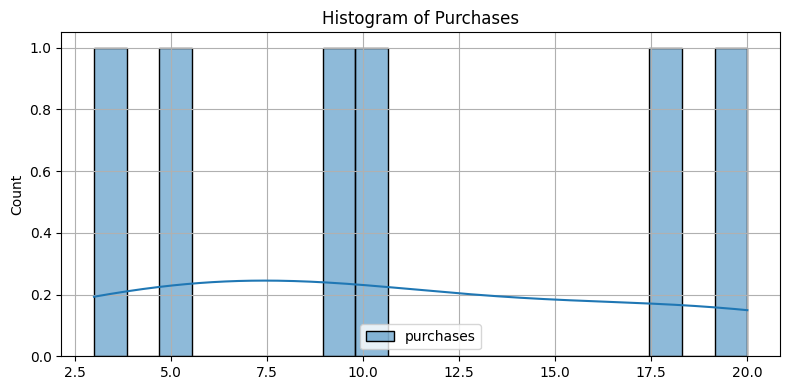

In [75]:
clean_purchase = pd.DataFrame(df["purchases"].dropna())
plt.figure(figsize=(8,4))
sns.histplot(clean_purchase, kde=True, bins=20)
plt.title("Histogram of Purchases")
plt.tight_layout()
plt.show()

*# Q4 – Student Answer Compact EDA using pandas
Plot: histogram of purchases :*

This plot shows the distribution of purchase values. Here we can see the most customers make a small number of purchases between 0 and 10. We also see some high purchases around 20, it means the distribution is slightly right skewed.

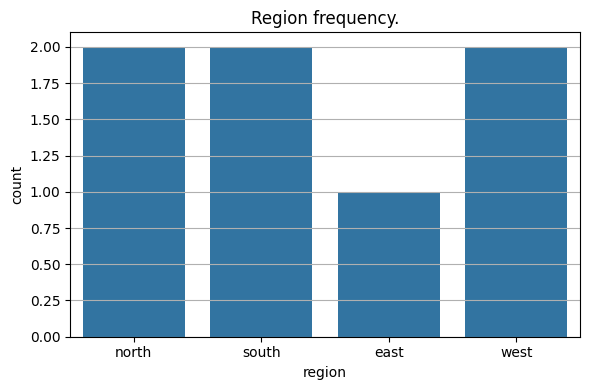

In [76]:
sns.countplot(x="region", data=df)
plt.title("Region frequency.")
plt.tight_layout()
plt.show()

*# Q4 – Student Answer Compact EDA using pandas
Plot: bar chart for region frequency :*

The barchart shows the frequency of data points across different regions. Here we can see the 'north', 'south' and 'west' regions appear most frequently two times, while the 'east' is observed only once in this dataset.

In [77]:
# Q4 – Student Answer
# Impute age with median
df['age']= df['age'].fillna(df['age'].median())
df

,age,region,purchases,premium_user
0,25.0,north,3.0,0
1,30.0,south,10.0,1
2,30.0,north,5.0,0
3,22.0,east,NaN,0
4,45.0,west,20.0,1
5,52.0,west,18.0,1
6,30.0,south,9.0,0


In [78]:
# Q4 – Student Answer
# Impute purchases with mean.

df['purchases']= df['purchases'].fillna(df['purchases'].mean())
df

,age,region,purchases,premium_user
0,25.0,north,3.000000,0
1,30.0,south,10.000000,1
2,30.0,north,5.000000,0
3,22.0,east,10.833333,0
4,45.0,west,20.000000,1
5,52.0,west,18.000000,1
6,30.0,south,9.000000,0


In [79]:
# Q4 – Student Answer
# One hot encode region

df = pd.get_dummies(df, columns=['region'], prefix='region', dtype=int)
df

,age,purchases,premium_user,region_east,region_north,region_south,region_west
0,25.0,3.000000,0,0,1,0,0
1,30.0,10.000000,1,0,0,1,0
2,30.0,5.000000,0,0,1,0,0
3,22.0,10.833333,0,1,0,0,0
4,45.0,20.000000,1,0,0,0,1
5,52.0,18.000000,1,0,0,0,1
6,30.0,9.000000,0,0,0,1,0


In [80]:
# Q4 – Student Answer
# Scale all numeric columns using RobustScaler.

num_cols_scale=["age","purchases"]
scaler = RobustScaler()
df[num_cols_scale]= scaler.fit_transform(df[num_cols_scale])

display(df)


,age,purchases,premium_user,region_east,region_north,region_south,region_west
0,-0.5,-0.943820,0,0,1,0,0
1,0.0,0.000000,1,0,0,1,0
2,0.0,-0.674157,0,0,1,0,0
3,-0.8,0.112360,0,1,0,0,0
4,1.5,1.348315,1,0,0,0,1
5,2.2,1.078652,1,0,0,0,1
6,0.0,-0.134831,0,0,0,1,0


In [81]:
# Q4 – Student Answer
# Create one domain driven feature : interaction like age * purchases
df['age_purchases_interaction'] = df['age'] * df['purchases']
df

,age,purchases,premium_user,region_east,region_north,region_south,region_west,age_purchases_interaction
0,-0.5,-0.943820,0,0,1,0,0,0.471910
1,0.0,0.000000,1,0,0,1,0,0.000000
2,0.0,-0.674157,0,0,1,0,0,-0.000000
3,-0.8,0.112360,0,1,0,0,0,-0.089888
4,1.5,1.348315,1,0,0,0,1,2.022472
5,2.2,1.078652,1,0,0,0,1,2.373034
6,0.0,-0.134831,0,0,0,1,0,-0.000000


In [82]:
# Q4 – Student Answer
# the final transformed dataframe ready for model training
display(df)


,age,purchases,premium_user,region_east,region_north,region_south,region_west,age_purchases_interaction
0,-0.5,-0.943820,0,0,1,0,0,0.471910
1,0.0,0.000000,1,0,0,1,0,0.000000
2,0.0,-0.674157,0,0,1,0,0,-0.000000
3,-0.8,0.112360,0,1,0,0,0,-0.089888
4,1.5,1.348315,1,0,0,0,1,2.022472
5,2.2,1.078652,1,0,0,0,1,2.373034
6,0.0,-0.134831,0,0,0,1,0,-0.000000


*# Q4 – Student Answer Explanations :*     


1.   Imputation : Here missing age and purchases values are filled with median and mean.
2.   Encoding : using the get_dummies we applied one hot encoding and converted the categorical region into binary values 0 and 1.
3.   Scaling : Using RobustScaler we scale the data for being resistant to outliers.
4.   Feature Engineering :  The age_purchases_interaction feature captures potential combined effects of age and spending habits.



---

### Q5. Applied Regression and Residual Analysis (20 marks)

We use this dataset:

```python
import pandas as pd

df2 = pd.DataFrame({
    "area_sqft": [800, 1000, 1200, 1500, 1800, 2000],
    "bedrooms": [2,2,3,3,4,4],
    "price": [120, 150, 170, 210, 260, 300]
})
```

**Tasks (20 marks total):**

1. Create the dataframe `df2`. (1 mark)  
2. Split the data into **train and test** with 80 percent train and 20 percent test. (3 marks)  
3. Fit a **LinearRegression** model to predict `price` from `area_sqft` and `bedrooms`. (4 marks)  
4. Print model **intercept**, **coefficients**, and **predictions** on the test set. (4 marks)  
5. Compute the following metrics on the test set. (6 marks)  
   - Mean Absolute Error (MAE)  
   - Root Mean Squared Error (RMSE)  
   - R squared (R²)  
6. Plot a **residual plot** with `y_true − y_pred` on the vertical axis and `y_pred` on the horizontal axis. (2 marks)  
   - Add a short note explaining what you observe from the residuals.

Again, use short markdown explanations to describe each step.


In [83]:
# Q5 – Student Answer

# Step 1: Create the dataframe
df2 = pd.DataFrame({
    "area_sqft": [800, 1000, 1200, 1500, 1800, 2000],
    "bedrooms": [2,2,3,3,4,4],
    "price": [120, 150, 170, 210, 260, 300]
})

df2

,area_sqft,bedrooms,price
0,800,2,120
1,1000,2,150
2,1200,3,170
3,1500,3,210
4,1800,4,260
5,2000,4,300


In [84]:
# Q5 – Student Answer
# Step 2: Split the data into train and test with 80 percent train and 20 percent test
X = df2[['area_sqft',	'bedrooms']]
y= df2['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [85]:
# Q5 – Student Answer
# Step 3: Fit a LinearRegression model to predict price from area_sqft and bedrooms
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
print("model trained")

model trained


In [86]:
# Q5 – Student Answer
# Step 4: Print model intercept, coefficients, and predictions on the test set
print("model intercept : ", lin_reg.intercept_)
print("model coefficients :", lin_reg.coef_[0])

y_pred = lin_reg.predict(X_test)
print("Test data :\n", X_test)
print("model predictions : ", y_pred)

model intercept :  -33.84615384615387
model coefficients : 0.15384615384615388
Test data :
    area_sqft  bedrooms
0        800         2
1       1000         2
model predictions :  [100.         130.76923077]


In [87]:
# Q5 – Student Answer
# Step 5: Compute the Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), R squared (R²)

mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE: ", mae)
print("RMSE: ", rmse)
print("R^2: ", r2)

MAE:  19.615384615384613
RMSE:  19.61915499208746
R^2:  -0.7107166337935567


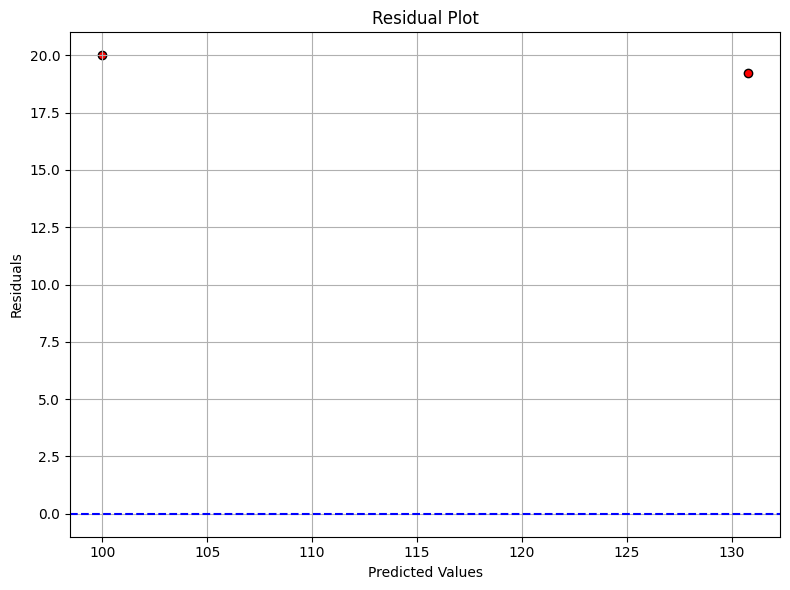

In [88]:
# Q5 – Student Answer
# Step 6: residual plot with y_true − y_pred on the vertical axis and y_pred on the horizontal axis

residuals = y_test - y_pred
# print(residuals)
plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, color='red', edgecolors='k')
plt.axhline(y=0, color='blue', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()

*# Q5 – Student Answer Step 6 residual plot explanation :*
Here we can see the residuals are all positive and clustered far from the 0 line and distributed around 19 to 20, which means tha model under predicting the actual house prices. Since the residuals do not appear to be randomly distributed around 0, it means the model has biasness becasue the trained dataset is so much smaller to find any pattern.

---

### Q6. Applied Classification, Metrics, Trees and ROC (20 marks)

We start with:

```python
import numpy as np

y_true = np.array([1,0,1,0,1,0,1,0,1,0])
y_prob = np.array([0.9,0.1,0.85,0.2,0.7,0.4,0.6,0.3,0.95,0.05])
```

**Part 1: Threshold based classification and metrics (8 marks)**

1. With threshold **0.5**, convert probabilities to class predictions. Then compute:  
   - Confusion matrix  
   - Precision  
   - Recall  
   - F1 score

2. With threshold **0.3**, convert probabilities to class predictions again and recompute the same metrics.

3. In 3 to 4 sentences, explain how lowering the threshold from 0.5 to 0.3 changed precision and recall and why this happens.

**Part 2: ROC and AUC (6 marks)**

4. Plot the **ROC curve** using `y_true` and `y_prob`.  
5. Compute the **AUC** and print it with 3 decimal places.  
6. Add a one or two line comment on what a high or low AUC means in this context.

**Part 3: Decision Tree on a small dataset (6 marks)**

Create this dataset:

```python
df3 = pd.DataFrame({
    "hours": [1,2,3,4,5,1,2,3,4,5],
    "passed": [0,0,0,1,1,0,0,1,1,1]
})
```

7. Fit a `DecisionTreeClassifier(max_depth=2)` to predict `passed` from `hours`.  
8. Plot the tree using `plot_tree`.  
9. Write 2 to 3 lines explaining whether the tree looks like it might **overfit** or **generalize well**, given the dataset size and the model depth.


In [89]:
# Q6 – Student Answer

# Part 1: threshold based classification
y_true = np.array([1,0,1,0,1,0,1,0,1,0])
y_prob = np.array([0.9,0.1,0.85,0.2,0.7,0.4,0.6,0.3,0.95,0.05])

# Write your code for threshold 0.5 and 0.3 below
# for 0.5 threshold
y_pred = (y_prob >= 0.5 ).astype(int)
cm = confusion_matrix(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("When threshold is 0.5 \n")
print("Confusion Matrix : \n", cm)
print("Precision : ", precision)
print("Recall : ", recall)
print("F1 Score : ", f1)

# for 0.5 threshold
y_pred = (y_prob >= 0.3 ).astype(int)
cm = confusion_matrix(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("\n\nWhen threshold is 0.3 \n")
print("Confusion Matrix : \n", cm)
print("Precision : ", precision)
print("Recall : ", recall)
print("F1 Score : ", f1)

When threshold is 0.5 

Confusion Matrix : 
 [[5 0]
 [0 5]]
Precision :  1.0
Recall :  1.0
F1 Score :  1.0


When threshold is 0.3 

Confusion Matrix : 
 [[3 2]
 [0 5]]
Precision :  0.7142857142857143
Recall :  1.0
F1 Score :  0.8333333333333334


*# Q6 – Student Answer Part 1: 3 to 4 sentences, how lowering the threshold from 0.5 to 0.3 changed precision and recall and why this happens. :*

When we lower the threshold 0.5 to 0.3 then the model becomes less strict on predicting a positive class. Recall stays same at 1.0, means all actual positive cases were predicted correctly at 0.5 remained same for 0.3. So lowering the threshold didn't capture any new positives, but it ensured no positives were missed.

Precision decreases 1.0 to 0.71 because the threshold is lower and the model now incorrectly classifies negative samples as positive.

Lowering the threshold generally increases the number of positive predictions. This boosts recall but risks lowering precision as more false alarms, because the model is more willing to label uncertain cases as positive.


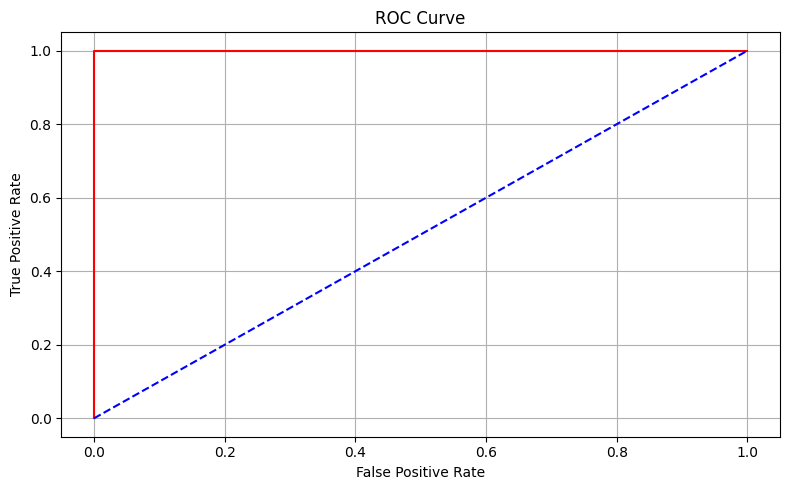


AUC : 1.000


In [90]:
# Q6 – Student Answer

# Part 2: ROC and AUC
fpr, tpr, thresholds= roc_curve(y_true, y_prob)
roc_auc= auc(fpr,tpr)

# print(fpr, tpr, thresholds)
# print()

plt.figure(figsize=(8,5))
plt.plot(fpr, tpr, color='red', label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], color='blue', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.tight_layout()
plt.show()
print(f"\nAUC : {roc_auc:.3f}")

*# Q6 – Student Answer Part 2: one or two line comment on what a high or low AUC means in this context :*

In this context a high AUC approaching 1.0 indicates that the model has excellent discriminative power, meaning it can almost perfectly distinguish between the positive class 1 and negative class 0 regardless of the chosen threshold. A low AUC approaching 0.5 would mean the model is just random guessing. It indicates a failure to find any meaningful patterns to separate the two classes.

In [91]:
# Q6 – Student Answer

# Part 3: Decision Tree on a small dataset

df3 = pd.DataFrame({
    "hours": [1,2,3,4,5,1,2,3,4,5],
    "passed": [0,0,0,1,1,0,0,1,1,1]
})
df3

,hours,passed
0,1,0
1,2,0
2,3,0
3,4,1
4,5,1
5,1,0
6,2,0
7,3,1
8,4,1
9,5,1


In [92]:
# Q6 – Student Answer

# Part 3: Fit a DecisionTreeClassifier(max_depth=2) to predict passed from hours
dct = DecisionTreeClassifier(max_depth=2)
X = df3[['hours']]
y = df3['passed']
dct.fit(X,y)

DecisionTreeClassifier(max_depth=2)

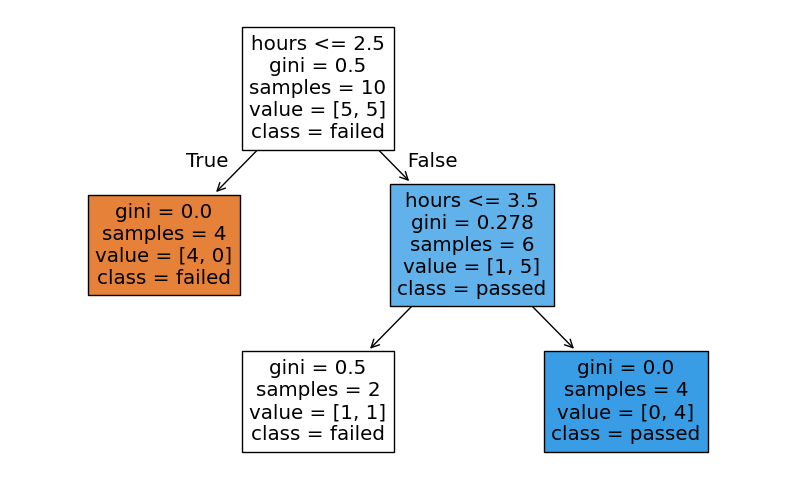

In [93]:
# Q6 – Student Answer

# Part 3: Plot the tree using plot_tree

plt.figure(figsize=(8,5))
plot_tree(dct, filled=True, feature_names=['hours'], class_names=['failed','passed'])
plt.tight_layout()
plt.show()

*# Q6 – Student Answer Part 3: 2 to 3 lines explaining whether the tree looks like it might overfit or generalize well, given the dataset size and the model depth :*

Based on the tree plot the model seems to generalize well rather than overfit. Even though the dataset is small with only 10 rows, the tree stays simple with just two main splits at 2.5 and 3.5 hours. Because the model doesn't get overly complecated or try to create a special rule for every single student, it does a good job of capturing the general pattern that studying more usually leads to passing without just memorizing the specific data points. The leaf nodes shows high purity as Gini = 0.0 for most after just two levels.